# MeatLens MobileNetV3Small Extension Notebook

This notebook is a clean **MobileNetV3Small-only extension notebook** for MeatLens.

Scope of this notebook:
- capture-source analysis
- center square ROI resized to `224x224`
- Grad-CAM interpretability for existing MobileNetV3Small baseline models
- MobileNetV3Small hybrid CNN + color/texture feature model

Guardrails:
- only `MobileNetV3Small` is used
- existing `new3.ipynb` is not modified
- existing baseline results are read-only
- all new outputs are written only inside `training_outputs/mobilenetv3small_extensions/`
- segmentation is included only as a visualization / future-work check


In [1]:
# ============================================================
# Imports
# ============================================================
import ast
import gc
import importlib
import json
import math
import random
import shutil
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    sns = None
    SEABORN_AVAILABLE = False

from PIL import Image, ImageOps
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

def optional_import(module_name):
    try:
        return importlib.import_module(module_name)
    except Exception:
        return None

try:
    import joblib
    JOBLIB_AVAILABLE = True
except Exception:
    joblib = None
    JOBLIB_AVAILABLE = False

cv2 = optional_import("cv2")
CV2_AVAILABLE = cv2 is not None

skcolor_module = optional_import("skimage.color")
skfeature_module = optional_import("skimage.feature")
skmorphology_module = optional_import("skimage.morphology")
skmeasure_module = optional_import("skimage.measure")

if all(mod is not None for mod in [skcolor_module, skfeature_module, skmorphology_module, skmeasure_module]):
    skcolor = skcolor_module
    graycomatrix = skfeature_module.graycomatrix
    graycoprops = skfeature_module.graycoprops
    binary_closing = skmorphology_module.binary_closing
    binary_opening = skmorphology_module.binary_opening
    disk = skmorphology_module.disk
    sk_label = skmeasure_module.label
    SKIMAGE_AVAILABLE = True
else:
    skcolor = None
    graycomatrix = None
    graycoprops = None
    binary_closing = None
    binary_opening = None
    disk = None
    sk_label = None
    SKIMAGE_AVAILABLE = False

TF_AVAILABLE = True
try:
    tf = optional_import("tensorflow")
    if tf is None:
        raise ImportError("tensorflow is not installed")

    layers = optional_import("tensorflow.keras.layers")
    models = optional_import("tensorflow.keras.models")
    callbacks_module = optional_import("tensorflow.keras.callbacks")
    applications_module = optional_import("tensorflow.keras.applications")
    mobilenet_v3_module = optional_import("tensorflow.keras.applications.mobilenet_v3")

    if None in [layers, models, callbacks_module, applications_module, mobilenet_v3_module]:
        raise ImportError("tensorflow.keras submodules are not fully available")

    Callback = callbacks_module.Callback
    EarlyStopping = callbacks_module.EarlyStopping
    ModelCheckpoint = callbacks_module.ModelCheckpoint
    ReduceLROnPlateau = callbacks_module.ReduceLROnPlateau
    MobileNetV3Small = applications_module.MobileNetV3Small
    preprocess_mobilenetv3 = mobilenet_v3_module.preprocess_input
except Exception as e:
    TF_AVAILABLE = False
    tf = None
    layers = None
    models = None
    Callback = object
    EarlyStopping = None
    ModelCheckpoint = None
    ReduceLROnPlateau = None
    MobileNetV3Small = None
    preprocess_mobilenetv3 = None
    print(f"[WARN] TensorFlow is not available: {e}")

plt.style.use("default")
warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True, precision=4)

print("TF_AVAILABLE =", TF_AVAILABLE)
print("CV2_AVAILABLE =", CV2_AVAILABLE)
print("SKIMAGE_AVAILABLE =", SKIMAGE_AVAILABLE)
print("JOBLIB_AVAILABLE =", JOBLIB_AVAILABLE)
print("SEABORN_AVAILABLE =", SEABORN_AVAILABLE)


TF_AVAILABLE = True
CV2_AVAILABLE = True
SKIMAGE_AVAILABLE = True
JOBLIB_AVAILABLE = True
SEABORN_AVAILABLE = True


In [2]:
# ============================================================
# Configuration
# ============================================================
PROJECT_ROOT = Path.cwd()
GENERATED_SPLITS_ROOT = PROJECT_ROOT / "generated_splits"
CROSS_ROTATION_ROOT = GENERATED_SPLITS_ROOT / "cross_rotation"
TRAINING_OUTPUTS_ROOT = PROJECT_ROOT / "training_outputs"
BASELINE_MODELS_ROOT = TRAINING_OUTPUTS_ROOT / "models"
BASELINE_SEED_METRICS_PATH = TRAINING_OUTPUTS_ROOT / "seed_metrics.csv"

EXTENSION_OUTPUT_ROOT = TRAINING_OUTPUTS_ROOT / "mobilenetv3small_extensions"
EXTENSION_FIGURES_ROOT = EXTENSION_OUTPUT_ROOT / "figures"
EXTENSION_MODELS_ROOT = EXTENSION_OUTPUT_ROOT / "models"
EXTENSION_FEATURES_ROOT = EXTENSION_OUTPUT_ROOT / "features"
EXTENSION_GRADCAM_ROOT = EXTENSION_OUTPUT_ROOT / "gradcam"
EXTENSION_SEGMENTATION_ROOT = EXTENSION_OUTPUT_ROOT / "segmentation"

for path_obj in [
    EXTENSION_OUTPUT_ROOT,
    EXTENSION_FIGURES_ROOT,
    EXTENSION_MODELS_ROOT,
    EXTENSION_FEATURES_ROOT,
    EXTENSION_GRADCAM_ROOT,
    EXTENSION_SEGMENTATION_ROOT,
]:
    path_obj.mkdir(parents=True, exist_ok=True)

EXTENSION_BACKBONE = "MobileNetV3Small"
EXTENSION_SPLIT_MODE = "cross_rotation"
EXTENSION_FOLDS = ["fold1", "fold2", "fold3", "fold4"]
EXTENSION_RUN_SEEDS = [42, 123, 2026]
RUN_EXTENSION_TRAINING = False
RUN_FEATURE_EXTRACTION = False
RUN_GRADCAM_BATCH = False
USE_HYBRID_AUGMENTATION = False

TARGET_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS_HEAD = 8
EPOCHS_FINE = 20
HEAD_LR = 5e-4
FINE_TUNE_LR = 1e-5
FINE_TUNE_FRACTION = 0.25
WEIGHT_DECAY = 1e-4

IMAGE_CROP_MODE = "center_square_resize_224"
MODEL_INPUT_MODE = "cnn_plus_color_texture"

LABEL_ORDER = ["fresh", "not fresh", "spoiled"]
LABEL_TO_INDEX = {label: idx for idx, label in enumerate(LABEL_ORDER)}
INDEX_TO_LABEL = {idx: label for label, idx in LABEL_TO_INDEX.items()}

SAMPLE_METADATA = {
    "pork_shoulder_sample_1": {"capture_source": "researcher_home", "pork_cut": "shoulder"},
    "pork_belly_sample_3": {"capture_source": "researcher_home", "pork_cut": "belly"},
    "pork_shoulder_sample_2": {"capture_source": "partner_home", "pork_cut": "shoulder"},
    "pork_belly_sample_4": {"capture_source": "partner_home", "pork_cut": "belly"},
}

SAMPLE_NUMBER_TO_ID = {
    "1": "pork_shoulder_sample_1",
    "2": "pork_shoulder_sample_2",
    "3": "pork_belly_sample_3",
    "4": "pork_belly_sample_4",
}

IMAGE_PATH_CANDIDATES = [
    "image_path",
    "file_path",
    "path",
    "filename",
    "image_file",
    "roi_file",
    "file_destination",
    "image_file_name",
]

CROSS_ROTATION_FILES = {
    f"{fold}_{part}": CROSS_ROTATION_ROOT / f"{fold}_{part}.csv"
    for fold in EXTENSION_FOLDS
    for part in ["train", "val", "test"]
}

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"EXTENSION_OUTPUT_ROOT = {EXTENSION_OUTPUT_ROOT}")
print(f"EXTENSION_BACKBONE = {EXTENSION_BACKBONE}")
print(f"EXTENSION_SPLIT_MODE = {EXTENSION_SPLIT_MODE}")
print(f"EXTENSION_FOLDS = {EXTENSION_FOLDS}")
print(f"EXTENSION_RUN_SEEDS = {EXTENSION_RUN_SEEDS}")
print(f"RUN_EXTENSION_TRAINING = {RUN_EXTENSION_TRAINING}")
print(f"RUN_FEATURE_EXTRACTION = {RUN_FEATURE_EXTRACTION}")
print(f"RUN_GRADCAM_BATCH = {RUN_GRADCAM_BATCH}")
print(f"USE_HYBRID_AUGMENTATION = {USE_HYBRID_AUGMENTATION}")


PROJECT_ROOT = e:\Thesis Code
EXTENSION_OUTPUT_ROOT = e:\Thesis Code\training_outputs\mobilenetv3small_extensions
EXTENSION_BACKBONE = MobileNetV3Small
EXTENSION_SPLIT_MODE = cross_rotation
EXTENSION_FOLDS = ['fold1', 'fold2', 'fold3', 'fold4']
EXTENSION_RUN_SEEDS = [42, 123, 2026]
RUN_EXTENSION_TRAINING = False
RUN_FEATURE_EXTRACTION = False
RUN_GRADCAM_BATCH = False
USE_HYBRID_AUGMENTATION = False


In [3]:
# ============================================================
# Split loading, path resolution, capture-source metadata
# ============================================================
def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    if TF_AVAILABLE:
        tf.random.set_seed(seed)


def detect_image_path_column(df: pd.DataFrame):
    for col_name in IMAGE_PATH_CANDIDATES:
        if col_name in df.columns:
            return col_name
    return None


def resolve_image_path(row, path_col, csv_path=None):
    if path_col is None:
        return None

    raw = row.get(path_col, None)
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None

    raw_str = str(raw).strip()
    if raw_str == "":
        return None

    candidates = []
    raw_path = Path(raw_str)
    candidates.append(raw_path)
    if csv_path is not None:
        candidates.append(Path(csv_path).resolve().parent / raw_str)
    candidates.append(PROJECT_ROOT / raw_str)

    for candidate in candidates:
        try:
            resolved = candidate.expanduser().resolve(strict=False)
        except Exception:
            resolved = candidate
        if Path(resolved).exists():
            return str(Path(resolved))
    return None


def load_split_dataframe(csv_path: Path, split_key: str):
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split file: {csv_path}")

    df = pd.read_csv(csv_path)
    df["split_key"] = split_key
    df["split_name"] = split_key.split("_")[0]
    df["dataset_partition"] = split_key.split("_")[1]

    path_col = detect_image_path_column(df)
    if path_col is None:
        raise ValueError(f"No image path column found in {csv_path.name}")

    df["image_path_source_column"] = path_col
    df["image_path_resolved"] = df.apply(
        lambda row: resolve_image_path(row, path_col=path_col, csv_path=csv_path),
        axis=1,
    )

    def _normalize_sample_id(row):
        sample_id_raw = row.get("sample_id", None)
        if sample_id_raw is not None and not (isinstance(sample_id_raw, float) and pd.isna(sample_id_raw)):
            sample_id_str = str(sample_id_raw).strip().lower()
            if sample_id_str not in ["", "nan", "none"]:
                return sample_id_str

        sample_number_raw = row.get("sample_number", None)
        if sample_number_raw is None or (isinstance(sample_number_raw, float) and pd.isna(sample_number_raw)):
            return None

        sample_number_str = str(sample_number_raw).strip()
        if sample_number_str.endswith(".0"):
            sample_number_str = sample_number_str[:-2]
        return SAMPLE_NUMBER_TO_ID.get(sample_number_str, None)

    df["sample_id"] = df.apply(_normalize_sample_id, axis=1)
    df["capture_source"] = df["sample_id"].map(lambda x: SAMPLE_METADATA.get(x, {}).get("capture_source"))
    df["pork_cut"] = df["sample_id"].map(lambda x: SAMPLE_METADATA.get(x, {}).get("pork_cut"))
    return df


SPLIT_DATA = {}
for split_key, csv_path in CROSS_ROTATION_FILES.items():
    SPLIT_DATA[split_key] = load_split_dataframe(csv_path, split_key=split_key)

CLEAN_SPLIT_DATA = {
    split_key: df.loc[~df["image_path_resolved"].isna()].reset_index(drop=True).copy()
    for split_key, df in SPLIT_DATA.items()
}

split_summary_rows = []
capture_distribution_rows = []
for split_key, df in SPLIT_DATA.items():
    split_summary_rows.append(
        {
            "split_key": split_key,
            "rows": int(len(df)),
            "resolved_rows": int(df["image_path_resolved"].notna().sum()),
            "missing_rows": int(df["image_path_resolved"].isna().sum()),
            "unmapped_capture_source_rows": int(df["capture_source"].isna().sum()),
            "unmapped_pork_cut_rows": int(df["pork_cut"].isna().sum()),
        }
    )

    grouped = (
        df.groupby(
            ["split_name", "dataset_partition", "capture_source", "pork_cut", "label", "sample_id"],
            dropna=False,
        )
        .size()
        .reset_index(name="count")
    )
    grouped.insert(0, "split_key", split_key)
    capture_distribution_rows.append(grouped)

SPLIT_SUMMARY_DF = pd.DataFrame(split_summary_rows)
CAPTURE_SOURCE_DISTRIBUTION_DF = pd.concat(capture_distribution_rows, ignore_index=True)

capture_distribution_path = EXTENSION_OUTPUT_ROOT / "capture_source_distribution_per_split.csv"
CAPTURE_SOURCE_DISTRIBUTION_DF.to_csv(capture_distribution_path, index=False)

print("Loaded split files:")
display(SPLIT_SUMMARY_DF)
print(f"Saved: {capture_distribution_path}")


Loaded split files:


,split_key,rows,resolved_rows,missing_rows,unmapped_capture_source_rows,unmapped_pork_cut_rows
0,fold1_train,1161,1161,0,0,0
1,fold1_val,205,205,0,0,0
2,fold1_test,485,485,0,0,0
3,fold2_train,1187,1187,0,0,0
4,fold2_val,210,210,0,0,0
5,fold2_test,454,454,0,0,0
6,fold3_train,1199,1199,0,0,0
7,fold3_val,212,212,0,0,0
8,fold3_test,440,440,0,0,0
9,fold4_train,1172,1172,0,0,0


Saved: e:\Thesis Code\training_outputs\mobilenetv3small_extensions\capture_source_distribution_per_split.csv


In [4]:
# ============================================================
# Capture-source mapping validation
# ============================================================
unmapped_rows = []
for split_key, df in SPLIT_DATA.items():
    bad = df.loc[df["capture_source"].isna() | df["pork_cut"].isna()].copy()
    if len(bad) > 0:
        bad.insert(0, "split_key", split_key)
        unmapped_rows.append(
            bad[
                [
                    "split_key",
                    "sample_id",
                    "label",
                    "image_path_source_column",
                    "image_path_resolved",
                    "capture_source",
                    "pork_cut",
                ]
            ]
        )

if len(unmapped_rows) == 0:
    print("All split rows were mapped successfully to capture_source and pork_cut.")
else:
    print("[WARN] Some rows are missing capture-source metadata:")
    display(pd.concat(unmapped_rows, ignore_index=True).head(20))

validation_preview = pd.concat(
    [
        CLEAN_SPLIT_DATA["fold1_train"][["sample_id", "capture_source", "pork_cut", "label", "image_path_resolved"]].head(5),
        CLEAN_SPLIT_DATA["fold2_test"][["sample_id", "capture_source", "pork_cut", "label", "image_path_resolved"]].head(5),
    ],
    ignore_index=True,
)
display(validation_preview)


All split rows were mapped successfully to capture_source and pork_cut.


,sample_id,capture_source,pork_cut,label,image_path_resolved
0,pork_shoulder_sample_2,partner_home,shoulder,not fresh,E:\Thesis Code\Pork Shoulder - sample 2\Not fr...
1,pork_belly_sample_4,partner_home,belly,fresh,E:\Thesis Code\Pork Belly - Sample 4\Fresh - 0...
2,pork_shoulder_sample_2,partner_home,shoulder,spoiled,E:\Thesis Code\Pork Shoulder - sample 2\Spoile...
3,pork_belly_sample_3,researcher_home,belly,not fresh,E:\Thesis Code\Pork Belly - Sample 3\Not Fresh...
4,pork_belly_sample_4,partner_home,belly,spoiled,E:\Thesis Code\Pork Belly - Sample 4\Spoiled -...
5,pork_shoulder_sample_2,partner_home,shoulder,fresh,E:\Thesis Code\Pork Shoulder - sample 2\Fresh ...
6,pork_shoulder_sample_2,partner_home,shoulder,fresh,E:\Thesis Code\Pork Shoulder - sample 2\Fresh ...
7,pork_shoulder_sample_2,partner_home,shoulder,fresh,E:\Thesis Code\Pork Shoulder - sample 2\Fresh ...
8,pork_shoulder_sample_2,partner_home,shoulder,fresh,E:\Thesis Code\Pork Shoulder - sample 2\Fresh ...
9,pork_shoulder_sample_2,partner_home,shoulder,fresh,E:\Thesis Code\Pork Shoulder - sample 2\Fresh ...


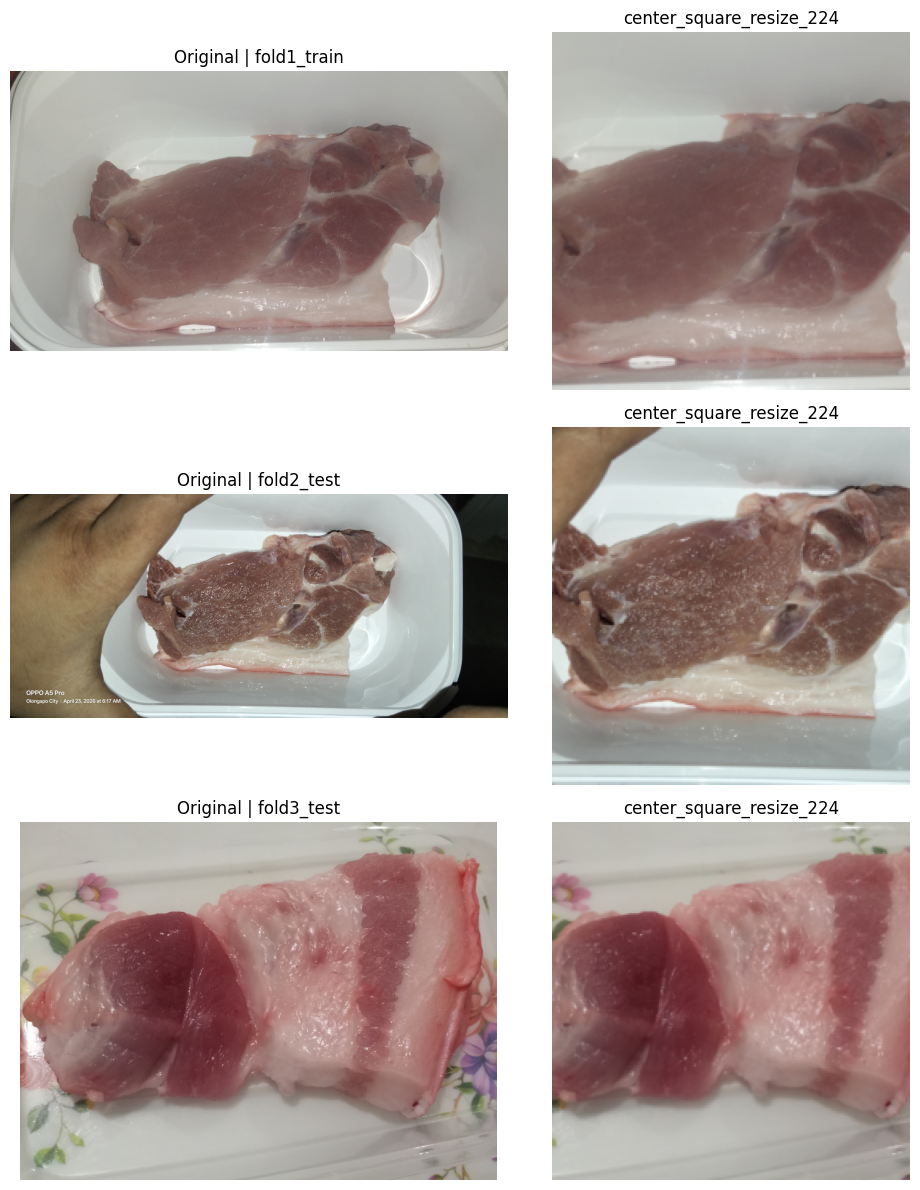

,split_key,sample_id,original_shape,processed_shape
0,fold1_train,pork_shoulder_sample_2,"(2304, 4096, 3)","(224, 224, 3)"
1,fold2_test,pork_shoulder_sample_2,"(1844, 4096, 3)","(224, 224, 3)"
2,fold3_test,pork_belly_sample_3,"(3456, 4608, 3)","(224, 224, 3)"


Processed image shape confirmations:
- fold1_train | pork_shoulder_sample_2 -> (224, 224, 3)
- fold2_test | pork_shoulder_sample_2 -> (224, 224, 3)
- fold3_test | pork_belly_sample_3 -> (224, 224, 3)
Saved: e:\Thesis Code\training_outputs\mobilenetv3small_extensions\figures\center_square_resize_224_examples.png


In [5]:
# ============================================================
# Main preprocessing: center square ROI resized to 224x224
# Exact 224x224 center crop is kept only as a debug helper
# ============================================================
def preprocess_exact_center_crop_224_debug(img: Image.Image):
    img = img.convert("RGB")
    width, height = img.size

    pad_left = max((224 - width) // 2, 0)
    pad_right = max(224 - width - pad_left, 0)
    pad_top = max((224 - height) // 2, 0)
    pad_bottom = max(224 - height - pad_top, 0)

    if any(v > 0 for v in [pad_left, pad_right, pad_top, pad_bottom]):
        img = ImageOps.expand(
            img,
            border=(pad_left, pad_top, pad_right, pad_bottom),
            fill=(0, 0, 0),
        )

    width, height = img.size
    left = (width - 224) // 2
    top = (height - 224) // 2
    cropped = img.crop((left, top, left + 224, top + 224))
    return cropped


def preprocess_center_square_resize_224(img: Image.Image):
    img = img.convert("RGB")
    width, height = img.size
    side = min(width, height)
    left = (width - side) // 2
    top = (height - side) // 2
    square = img.crop((left, top, left + side, top + side))
    square_resized = square.resize((224, 224), Image.BILINEAR)
    return square_resized


def load_center_square_resize_224(path):
    img = Image.open(path).convert("RGB")
    original_np = np.array(img)
    cropped = preprocess_center_square_resize_224(img)
    cropped_np = np.array(cropped)
    cropped_float = cropped_np.astype(np.float32) / 255.0
    return original_np, cropped_np, cropped_float


def load_exact_center_crop_224_debug(path):
    img = Image.open(path).convert("RGB")
    original_np = np.array(img)
    cropped = preprocess_exact_center_crop_224_debug(img)
    cropped_np = np.array(cropped)
    cropped_float = cropped_np.astype(np.float32) / 255.0
    return original_np, cropped_np, cropped_float


example_rows = []
for split_key in ["fold1_train", "fold2_test", "fold3_test", "fold4_test"]:
    df = CLEAN_SPLIT_DATA.get(split_key, pd.DataFrame())
    if len(df) == 0:
        continue
    example_rows.append((split_key, df.iloc[0]))
    if len(example_rows) >= 3:
        break

if len(example_rows) == 0:
    print("No valid images found for center_square_resize_224 visualization.")
else:
    fig, axes = plt.subplots(len(example_rows), 2, figsize=(10, 4 * len(example_rows)))
    if len(example_rows) == 1:
        axes = np.array([axes])

    shape_records = []
    for row_idx, (split_key, row) in enumerate(example_rows):
        original_np, cropped_np, _ = load_center_square_resize_224(row["image_path_resolved"])
        shape_records.append(
            {
                "split_key": split_key,
                "sample_id": row["sample_id"],
                "original_shape": tuple(original_np.shape),
                "processed_shape": tuple(cropped_np.shape),
            }
        )
        axes[row_idx, 0].imshow(original_np)
        axes[row_idx, 0].set_title(f"Original | {split_key}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(cropped_np)
        axes[row_idx, 1].set_title("center_square_resize_224")
        axes[row_idx, 1].axis("off")

    plt.tight_layout()
    center_crop_path = EXTENSION_FIGURES_ROOT / "center_square_resize_224_examples.png"
    plt.savefig(center_crop_path, dpi=200, bbox_inches="tight")
    plt.show()

    shape_df = pd.DataFrame(shape_records)
    display(shape_df)
    print("Processed image shape confirmations:")
    for _, rec in shape_df.iterrows():
        print(f"- {rec['split_key']} | {rec['sample_id']} -> {rec['processed_shape']}")
    print(f"Saved: {center_crop_path}")


In [6]:
# ============================================================
# Color / texture feature extraction check for 3 images
# ============================================================
FEATURE_WARNING_STATE = {"lab_warned": False, "glcm_warned": False}


def rgb_channel_stats(image_uint8):
    out = {}
    channel_names = ["r", "g", "b"]
    for idx, name in enumerate(channel_names):
        channel = image_uint8[:, :, idx].astype(np.float32)
        out[f"rgb_mean_{name}"] = float(channel.mean())
        out[f"rgb_std_{name}"] = float(channel.std())
    return out


def hsv_channel_stats(image_uint8):
    hsv = np.array(Image.fromarray(image_uint8, mode="RGB").convert("HSV"), dtype=np.float32)
    out = {}
    channel_names = ["h", "s", "v"]
    for idx, name in enumerate(channel_names):
        channel = hsv[:, :, idx]
        out[f"hsv_mean_{name}"] = float(channel.mean())
        out[f"hsv_std_{name}"] = float(channel.std())
    return out


def lab_channel_stats(image_uint8):
    if not SKIMAGE_AVAILABLE:
        if not FEATURE_WARNING_STATE["lab_warned"]:
            print("[WARN] scikit-image is unavailable. LAB features will be skipped.")
            FEATURE_WARNING_STATE["lab_warned"] = True
        return {}
    lab = skcolor.rgb2lab(image_uint8 / 255.0).astype(np.float32)
    out = {}
    channel_names = ["l", "a", "b"]
    for idx, name in enumerate(channel_names):
        channel = lab[:, :, idx]
        out[f"lab_mean_{name}"] = float(channel.mean())
        out[f"lab_std_{name}"] = float(channel.std())
    return out


def glcm_texture_stats(image_uint8):
    if not SKIMAGE_AVAILABLE:
        if not FEATURE_WARNING_STATE["glcm_warned"]:
            print("[WARN] scikit-image is unavailable. GLCM texture features will be skipped.")
            FEATURE_WARNING_STATE["glcm_warned"] = True
        return {}

    gray = np.array(Image.fromarray(image_uint8, mode="RGB").convert("L"), dtype=np.uint8)
    distances = [1, 2, 4]
    angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    glcm = graycomatrix(
        gray,
        distances=distances,
        angles=angles,
        levels=256,
        symmetric=True,
        normed=True,
    )
    properties = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
    out = {}
    for prop_name in properties:
        values = graycoprops(glcm, prop_name).astype(np.float32).ravel()
        out[f"glcm_{prop_name.lower()}_mean"] = float(values.mean())
        out[f"glcm_{prop_name.lower()}_std"] = float(values.std())
    return out


def extract_color_texture_features_from_uint8(image_uint8):
    feats = {}
    feats.update(rgb_channel_stats(image_uint8))
    feats.update(hsv_channel_stats(image_uint8))
    feats.update(lab_channel_stats(image_uint8))
    feats.update(glcm_texture_stats(image_uint8))
    return feats


def extract_feature_record(row, split_key):
    _, crop_uint8, _ = load_center_square_resize_224(row["image_path_resolved"])
    record = {
        "split_key": split_key,
        "sample_id": row["sample_id"],
        "capture_source": row["capture_source"],
        "pork_cut": row["pork_cut"],
        "label": row["label"],
        "image_path_resolved": row["image_path_resolved"],
    }
    record.update(extract_color_texture_features_from_uint8(crop_uint8))
    return record


sample_feature_rows = []
for split_key in ["fold1_train", "fold2_test", "fold3_test", "fold4_test"]:
    df = CLEAN_SPLIT_DATA.get(split_key, pd.DataFrame())
    if len(df) == 0:
        continue
    sample_feature_rows.append(extract_feature_record(df.iloc[0], split_key=split_key))
    if len(sample_feature_rows) >= 3:
        break

sample_feature_df = pd.DataFrame(sample_feature_rows)
sample_feature_path = EXTENSION_FEATURES_ROOT / "example_3_images_color_texture_features.csv"
sample_feature_df.to_csv(sample_feature_path, index=False)
display(sample_feature_df)
print(f"Saved: {sample_feature_path}")


,split_key,sample_id,capture_source,pork_cut,label,image_path_resolved,rgb_mean_r,rgb_std_r,rgb_mean_g,rgb_std_g,...,glcm_dissimilarity_mean,glcm_dissimilarity_std,glcm_homogeneity_mean,glcm_homogeneity_std,glcm_energy_mean,glcm_energy_std,glcm_correlation_mean,glcm_correlation_std,glcm_asm_mean,glcm_asm_std
0,fold1_train,pork_shoulder_sample_2,partner_home,shoulder,not fresh,E:\Thesis Code\Pork Shoulder - sample 2\Not fr...,150.404037,35.112652,132.462936,48.381535,...,4.424531,2.181512,0.371864,0.099864,0.034725,0.006039,0.978243,0.019392,0.001242,0.000418
1,fold2_test,pork_shoulder_sample_2,partner_home,shoulder,fresh,E:\Thesis Code\Pork Shoulder - sample 2\Fresh ...,157.470459,38.334633,145.529556,53.111969,...,9.344711,3.591595,0.234853,0.083160,0.020696,0.004620,0.939590,0.040970,0.000450,0.000206
2,fold3_test,pork_belly_sample_3,researcher_home,belly,fresh,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...,161.244995,30.922884,131.307556,49.291424,...,5.242524,2.091972,0.301758,0.085688,0.031750,0.006926,0.976979,0.015923,0.001056,0.000445


Saved: e:\Thesis Code\training_outputs\mobilenetv3small_extensions\features\example_3_images_color_texture_features.csv


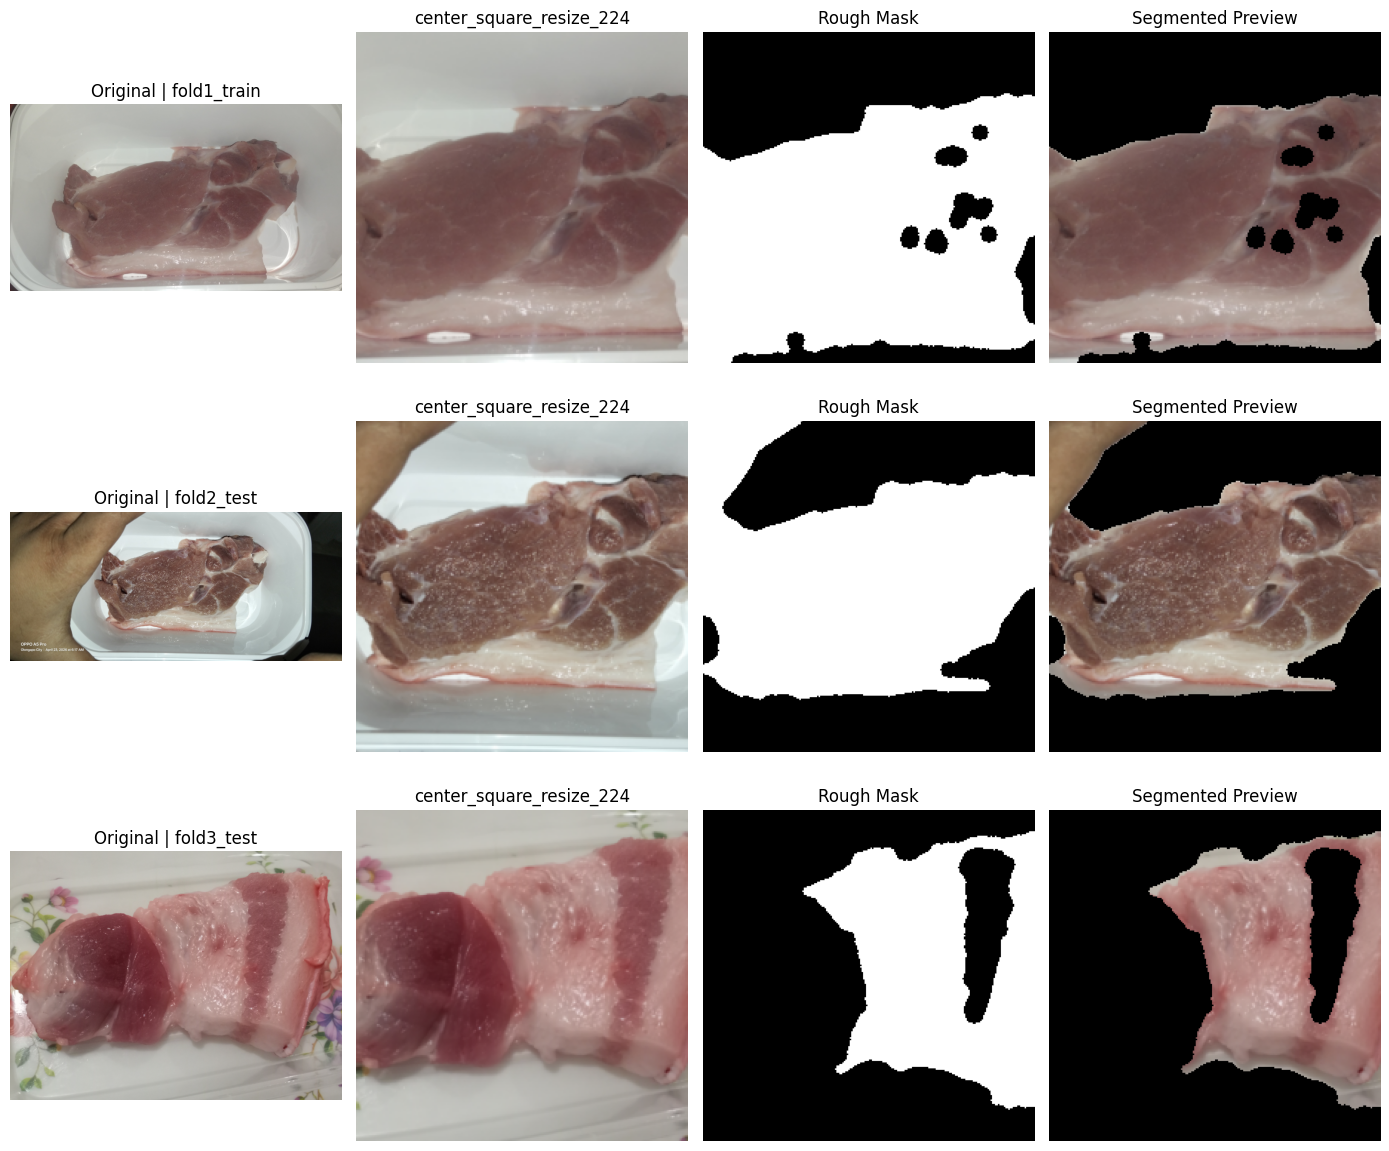

Saved classical color-threshold segmentation visualization only:
e:\Thesis Code\training_outputs\mobilenetv3small_extensions\segmentation\segmentation_examples.png


In [7]:
# ============================================================
# Optional classical color-threshold segmentation visualization only
# ============================================================
def build_classical_segmentation_preview(image_uint8):
    if not (CV2_AVAILABLE or SKIMAGE_AVAILABLE):
        print("[WARN] cv2 / scikit-image unavailable. Segmentation visualization is skipped safely.")
        return None

    hsv = np.array(Image.fromarray(image_uint8, mode="RGB").convert("HSV"), dtype=np.uint8)
    h = hsv[:, :, 0].astype(np.float32)
    s = hsv[:, :, 1].astype(np.float32)
    v = hsv[:, :, 2].astype(np.float32)

    mask = (
        (h >= 0) & (h <= 35) &
        (s >= 20) & (s <= 220) &
        (v >= 40) & (v <= 255)
    )

    if SKIMAGE_AVAILABLE:
        mask = binary_opening(mask, disk(3))
        mask = binary_closing(mask, disk(5))
        labels = sk_label(mask.astype(np.uint8))
        if labels.max() > 0:
            counts = np.bincount(labels.ravel())
            counts[0] = 0
            mask = labels == counts.argmax()
    elif CV2_AVAILABLE:
        kernel_open = np.ones((3, 3), np.uint8)
        kernel_close = np.ones((5, 5), np.uint8)
        mask_uint8 = (mask.astype(np.uint8) * 255)
        mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel_open)
        mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel_close)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
        if num_labels > 1:
            largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            mask_uint8 = np.where(labels == largest_idx, 255, 0).astype(np.uint8)
        mask = mask_uint8 > 0

    segmented = image_uint8.copy()
    segmented[~mask] = 0
    return {
        "mask": mask.astype(np.uint8) * 255,
        "segmented": segmented,
    }


seg_rows = []
for split_key in ["fold1_train", "fold2_test", "fold3_test", "fold4_test"]:
    df = CLEAN_SPLIT_DATA.get(split_key, pd.DataFrame())
    if len(df) == 0:
        continue
    seg_rows.append((split_key, df.iloc[0]))
    if len(seg_rows) >= 3:
        break

if len(seg_rows) == 0:
    print("No valid images available for segmentation preview.")
else:
    previews = []
    for split_key, row in seg_rows:
        original_np, crop_uint8, _ = load_center_square_resize_224(row["image_path_resolved"])
        preview = build_classical_segmentation_preview(crop_uint8)
        previews.append((split_key, row, original_np, crop_uint8, preview))

    valid_previews = [item for item in previews if item[4] is not None]
    if len(valid_previews) == 0:
        print("Segmentation preview skipped because required image-processing libraries are unavailable.")
    else:
        fig, axes = plt.subplots(len(valid_previews), 4, figsize=(14, 4 * len(valid_previews)))
        if len(valid_previews) == 1:
            axes = np.array([axes])

        for row_idx, (split_key, row, original_np, crop_uint8, preview) in enumerate(valid_previews):
            axes[row_idx, 0].imshow(original_np)
            axes[row_idx, 0].set_title(f"Original | {split_key}")
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(crop_uint8)
            axes[row_idx, 1].set_title("center_square_resize_224")
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(preview["mask"], cmap="gray")
            axes[row_idx, 2].set_title("Rough Mask")
            axes[row_idx, 2].axis("off")

            axes[row_idx, 3].imshow(preview["segmented"])
            axes[row_idx, 3].set_title("Segmented Preview")
            axes[row_idx, 3].axis("off")

        plt.tight_layout()
        segmentation_path = EXTENSION_SEGMENTATION_ROOT / "segmentation_examples.png"
        plt.savefig(segmentation_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved classical color-threshold segmentation visualization only:")
        print(segmentation_path)


## Extended Analysis And Training Utilities

The cells below define the remaining notebook workflow:
- baseline capture-source summaries from existing `training_outputs/seed_metrics.csv`
- optional full handcrafted feature extraction
- optional Grad-CAM generation for existing MobileNetV3Small baseline models
- MobileNetV3Small hybrid model training and result summaries
- baseline-versus-hybrid reporting


In [ ]:
# ============================================================
# Existing baseline capture-source analysis
# ============================================================
def _safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def _plot_simple_bar(df, x_col, y_col, title, out_path, color="#4C78A8", rotate_xticks=False):
    if len(df) == 0:
        print(f"[WARN] No data available for {out_path.name}")
        return
    plt.figure(figsize=(8, 5))
    plt.bar(df[x_col].astype(str), df[y_col].astype(float), color=color)
    plt.title(title)
    plt.ylabel(y_col)
    plt.xlabel(x_col)
    if rotate_xticks:
        plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


if BASELINE_SEED_METRICS_PATH.exists():
    baseline_df = pd.read_csv(BASELINE_SEED_METRICS_PATH)
    baseline_df = baseline_df.loc[
        (baseline_df["backbone"] == "MobileNetV3Small")
        & (baseline_df["split_mode"] == "cross_rotation")
    ].copy()

    if len(baseline_df) == 0:
        print("No existing MobileNetV3Small cross_rotation baseline rows found.")
    else:
        baseline_df["seed"] = _safe_numeric(baseline_df["seed"])
        baseline_df["accuracy"] = _safe_numeric(baseline_df["accuracy"])
        baseline_df["macro_f1"] = _safe_numeric(baseline_df["macro_f1"])
        baseline_df["held_out_sample"] = baseline_df["held_out_sample"].astype(str).str.strip().str.lower()
        baseline_df["capture_source"] = baseline_df["held_out_sample"].map(
            lambda x: SAMPLE_METADATA.get(x, {}).get("capture_source")
        )
        baseline_df["pork_cut"] = baseline_df["held_out_sample"].map(
            lambda x: SAMPLE_METADATA.get(x, {}).get("pork_cut")
        )

        by_capture_source = (
            baseline_df.groupby("capture_source", dropna=False)
            .agg(
                runs=("run_stem", "count"),
                accuracy_mean=("accuracy", "mean"),
                accuracy_std=("accuracy", "std"),
                macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
            )
            .reset_index()
        )
        by_held_out_sample = (
            baseline_df.groupby(["held_out_sample", "capture_source", "pork_cut"], dropna=False)
            .agg(
                runs=("run_stem", "count"),
                accuracy_mean=("accuracy", "mean"),
                accuracy_std=("accuracy", "std"),
                macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
            )
            .reset_index()
            .sort_values("held_out_sample")
        )
        by_pork_cut = (
            baseline_df.groupby("pork_cut", dropna=False)
            .agg(
                runs=("run_stem", "count"),
                accuracy_mean=("accuracy", "mean"),
                accuracy_std=("accuracy", "std"),
                macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
            )
            .reset_index()
        )

        by_capture_source.to_csv(EXTENSION_OUTPUT_ROOT / "performance_by_capture_source.csv", index=False)
        by_held_out_sample.to_csv(EXTENSION_OUTPUT_ROOT / "performance_by_held_out_sample.csv", index=False)
        by_pork_cut.to_csv(EXTENSION_OUTPUT_ROOT / "performance_by_pork_cut.csv", index=False)

        _plot_simple_bar(
            by_held_out_sample,
            x_col="held_out_sample",
            y_col="macro_f1_mean",
            title="Baseline Macro F1 by Held-Out Sample",
            out_path=EXTENSION_FIGURES_ROOT / "macro_f1_by_held_out_sample.png",
            color="#2E86AB",
            rotate_xticks=True,
        )
        _plot_simple_bar(
            by_capture_source,
            x_col="capture_source",
            y_col="macro_f1_mean",
            title="Baseline Macro F1 by Capture Source",
            out_path=EXTENSION_FIGURES_ROOT / "macro_f1_by_capture_source.png",
            color="#F18F01",
        )
        _plot_simple_bar(
            by_pork_cut,
            x_col="pork_cut",
            y_col="macro_f1_mean",
            title="Baseline Macro F1 by Pork Cut",
            out_path=EXTENSION_FIGURES_ROOT / "macro_f1_by_pork_cut.png",
            color="#C73E1D",
        )
        _plot_simple_bar(
            by_capture_source,
            x_col="capture_source",
            y_col="accuracy_mean",
            title="Baseline Accuracy by Capture Source",
            out_path=EXTENSION_FIGURES_ROOT / "accuracy_by_capture_source.png",
            color="#4C9F70",
        )
else:
    print(f"Baseline file not found: {BASELINE_SEED_METRICS_PATH}")


In [ ]:
# ============================================================
# Optional full handcrafted feature extraction
# ============================================================
def build_feature_dataframe_for_split(df, split_key):
    records = []
    for _, row in df.iterrows():
        try:
            records.append(extract_feature_record(row, split_key=split_key))
        except Exception as exc:
            print(f"[WARN] Feature extraction failed for {row.get('image_path_resolved')}: {exc}")
    out_df = pd.DataFrame(records)
    return out_df


def save_full_feature_tables():
    for fold_name in EXTENSION_FOLDS:
        for part_name in ["train", "val", "test"]:
            split_key = f"{fold_name}_{part_name}"
            df = CLEAN_SPLIT_DATA[split_key]
            feature_df = build_feature_dataframe_for_split(df, split_key=split_key)
            out_path = EXTENSION_FEATURES_ROOT / f"{split_key}_color_texture_features.csv"
            feature_df.to_csv(out_path, index=False)
            print(f"Saved {out_path} ({len(feature_df)} rows)")


if RUN_FEATURE_EXTRACTION:
    save_full_feature_tables()
else:
    print("RUN_FEATURE_EXTRACTION=False -> full handcrafted feature extraction is skipped.")


In [ ]:
# ============================================================
# Grad-CAM for existing MobileNetV3Small baseline models
# ============================================================
def find_mobilenetv3small_backbone_layer(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            layer_name = str(layer.name).lower()
            if "mobilenetv3" in layer_name or "mobilenet_v3" in layer_name:
                return layer
    raise ValueError("Could not find the nested MobileNetV3Small backbone inside the model.")


def make_gradcam_heatmap(model, image_batch, class_index=None, backbone_layer=None):
    if backbone_layer is None:
        backbone_layer = find_mobilenetv3small_backbone_layer(model)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[backbone_layer.output, model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_batch)
        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap_on_image(image_uint8, heatmap, alpha=0.40):
    heatmap_uint8 = np.uint8(255 * np.clip(heatmap, 0, 1))
    if CV2_AVAILABLE:
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    else:
        cmap = plt.cm.jet(heatmap)[:, :, :3]
        heatmap_color = np.uint8(cmap * 255)
    heatmap_color = np.array(Image.fromarray(heatmap_color).resize((224, 224)))
    overlay = np.clip((1 - alpha) * image_uint8 + alpha * heatmap_color, 0, 255).astype(np.uint8)
    return heatmap_uint8, overlay


def select_gradcam_candidates(pred_df, limit_per_class=3):
    chosen_indices = []
    for target_mode in ["correct", "misclassified"]:
        for class_name in LABEL_ORDER:
            if target_mode == "correct":
                subset = pred_df.loc[(pred_df["true_label"] == class_name) & (pred_df["pred_label"] == class_name)]
            else:
                subset = pred_df.loc[(pred_df["true_label"] == class_name) & (pred_df["pred_label"] != class_name)]
            chosen_indices.extend(subset.head(limit_per_class).index.tolist())
    return pred_df.loc[sorted(set(chosen_indices))].copy()


def evaluate_existing_baseline_model_for_gradcam(metric_row):
    split_name = metric_row["split_name"]
    model_path = Path(metric_row["model_h5_path"])
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    model = tf.keras.models.load_model(model_path, compile=False)
    backbone_layer = find_mobilenetv3small_backbone_layer(model)
    test_df = CLEAN_SPLIT_DATA[f"{split_name}_test"].copy().reset_index(drop=True)

    pred_records = []
    for idx, row in test_df.iterrows():
        _, crop_uint8, crop_float = load_center_square_resize_224(row["image_path_resolved"])
        input_tensor = preprocess_mobilenetv3(np.expand_dims(crop_float * 255.0, axis=0))
        preds = model.predict(input_tensor, verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        pred_records.append(
            {
                "row_index": idx,
                "image_path_resolved": row["image_path_resolved"],
                "true_label": row["label"],
                "pred_label": INDEX_TO_LABEL[pred_idx],
                "confidence": float(np.max(preds)),
                "pred_index": pred_idx,
                "split_name": split_name,
                "seed": int(metric_row["seed"]),
                "run_stem": metric_row["run_stem"],
            }
        )

    pred_df = pd.DataFrame(pred_records)
    candidate_df = select_gradcam_candidates(pred_df, limit_per_class=3)
    saved_rows = []

    for _, candidate in candidate_df.iterrows():
        row = test_df.iloc[int(candidate["row_index"])]
        original_np, crop_uint8, crop_float = load_center_square_resize_224(row["image_path_resolved"])
        input_tensor = preprocess_mobilenetv3(np.expand_dims(crop_float * 255.0, axis=0))
        heatmap = make_gradcam_heatmap(
            model=model,
            image_batch=input_tensor,
            class_index=int(candidate["pred_index"]),
            backbone_layer=backbone_layer,
        )
        heatmap_uint8, overlay = overlay_heatmap_on_image(crop_uint8, heatmap)

        fig, axes = plt.subplots(1, 4, figsize=(14, 4))
        axes[0].imshow(original_np)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(crop_uint8)
        axes[1].set_title("center_square_resize_224")
        axes[1].axis("off")

        axes[2].imshow(heatmap_uint8, cmap="jet")
        axes[2].set_title("Grad-CAM Heatmap")
        axes[2].axis("off")

        axes[3].imshow(overlay)
        axes[3].set_title("Overlay")
        axes[3].axis("off")

        fig.suptitle(
            f"{candidate['run_stem']} | true={candidate['true_label']} | pred={candidate['pred_label']} | conf={candidate['confidence']:.3f}",
            fontsize=10,
        )
        plt.tight_layout()
        out_name = (
            f"{candidate['run_stem']}_row{int(candidate['row_index']):04d}_"
            f"true_{candidate['true_label'].replace(' ', '_')}_"
            f"pred_{candidate['pred_label'].replace(' ', '_')}.png"
        )
        out_path = EXTENSION_GRADCAM_ROOT / out_name
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.close(fig)

        saved_rows.append(
            {
                "run_stem": candidate["run_stem"],
                "fold": candidate["split_name"],
                "seed": candidate["seed"],
                "image_path_resolved": candidate["image_path_resolved"],
                "true_label": candidate["true_label"],
                "pred_label": candidate["pred_label"],
                "confidence": candidate["confidence"],
                "gradcam_path": str(out_path),
            }
        )

    del model
    gc.collect()
    if TF_AVAILABLE:
        tf.keras.backend.clear_session()
    return pd.DataFrame(saved_rows)


def run_gradcam_batch():
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is required for Grad-CAM.")
    if not BASELINE_SEED_METRICS_PATH.exists():
        raise FileNotFoundError(f"Missing baseline metrics: {BASELINE_SEED_METRICS_PATH}")

    baseline_df = pd.read_csv(BASELINE_SEED_METRICS_PATH)
    baseline_df = baseline_df.loc[
        (baseline_df["backbone"] == "MobileNetV3Small")
        & (baseline_df["split_mode"] == "cross_rotation")
    ].copy()
    baseline_df["macro_f1"] = pd.to_numeric(baseline_df["macro_f1"], errors="coerce")
    baseline_df["seed"] = pd.to_numeric(baseline_df["seed"], errors="coerce")
    baseline_df = baseline_df.dropna(subset=["macro_f1"]).sort_values("macro_f1")

    if len(baseline_df) == 0:
        print("No valid MobileNetV3Small baseline rows available for Grad-CAM.")
        return pd.DataFrame()

    selected_rows = pd.concat([baseline_df.head(1), baseline_df.tail(1)], ignore_index=True).drop_duplicates("run_stem")
    summary_frames = []
    for _, metric_row in selected_rows.iterrows():
        print(f"Generating Grad-CAM samples for {metric_row['run_stem']}")
        summary_frames.append(evaluate_existing_baseline_model_for_gradcam(metric_row))

    summary_df = pd.concat(summary_frames, ignore_index=True) if len(summary_frames) > 0 else pd.DataFrame()
    summary_path = EXTENSION_GRADCAM_ROOT / "gradcam_samples_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"Saved: {summary_path}")
    return summary_df


if RUN_GRADCAM_BATCH:
    gradcam_summary_df = run_gradcam_batch()
    display(gradcam_summary_df.head())
else:
    print("RUN_GRADCAM_BATCH=False -> Grad-CAM functions are ready but batch generation is skipped.")


In [ ]:
# ============================================================
# Hybrid dataset and model helpers
# ============================================================
ADAMW_WARNING_PRINTED = False


def build_optimizer(learning_rate):
    global ADAMW_WARNING_PRINTED
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is unavailable.")
    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=WEIGHT_DECAY,
        )
        return optimizer
    except Exception:
        if not ADAMW_WARNING_PRINTED:
            print("[WARN] AdamW is not available. Falling back to Adam without decoupled weight decay.")
            ADAMW_WARNING_PRINTED = True
        return tf.keras.optimizers.Adam(learning_rate=learning_rate)


def compute_class_weights_from_labels(label_series):
    y = label_series.map(LABEL_TO_INDEX)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array(sorted(LABEL_TO_INDEX.values())),
        y=y.values,
    )
    return {idx: float(weight) for idx, weight in zip(sorted(LABEL_TO_INDEX.values()), weights)}


def prepare_feature_tables_for_fold(fold_name, seed):
    split_frames = {}
    for part_name in ["train", "val", "test"]:
        split_key = f"{fold_name}_{part_name}"
        out_path = EXTENSION_FEATURES_ROOT / f"{split_key}_color_texture_features.csv"
        if out_path.exists():
            ft_df = pd.read_csv(out_path)
        else:
            ft_df = build_feature_dataframe_for_split(CLEAN_SPLIT_DATA[split_key], split_key=split_key)
            ft_df.to_csv(out_path, index=False)
        split_frames[part_name] = ft_df

    train_df = split_frames["train"].copy()
    val_df = split_frames["val"].copy()
    test_df = split_frames["test"].copy()

    feature_columns = [
        c for c in train_df.columns
        if c not in ["split_key", "sample_id", "capture_source", "pork_cut", "label", "image_path_resolved"]
    ]
    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_df[feature_columns].astype(np.float32))
    val_features = scaler.transform(val_df[feature_columns].astype(np.float32))
    test_features = scaler.transform(test_df[feature_columns].astype(np.float32))

    scaler_path = ""
    if JOBLIB_AVAILABLE:
        scaler_path_obj = EXTENSION_FEATURES_ROOT / f"{fold_name}_seed{seed}_color_texture_scaler.joblib"
        joblib.dump(scaler, scaler_path_obj)
        scaler_path = str(scaler_path_obj)
        print(f"Saved scaler: {scaler_path_obj}")
    else:
        print("[WARN] joblib is unavailable. Scaler serialization skipped.")

    return {
        "feature_columns": feature_columns,
        "scaler_path": scaler_path,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "train_features": train_features.astype(np.float32),
        "val_features": val_features.astype(np.float32),
        "test_features": test_features.astype(np.float32),
    }


def _depthwise_filter_rgb(img, kernel_2d):
    kernel = tf.constant(kernel_2d, dtype=tf.float32)
    kernel = tf.reshape(kernel, [3, 3, 1, 1])
    kernel = tf.repeat(kernel, repeats=3, axis=2)
    x = tf.expand_dims(img, axis=0)
    y = tf.nn.depthwise_conv2d(x, kernel, strides=[1, 1, 1, 1], padding="SAME")
    return tf.squeeze(y, axis=0)


def _apply_mild_augmentation_tf(img):
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = tf.image.adjust_brightness(img, delta=tf.random.uniform([], -0.04, 0.04))
    contrast_factor = tf.random.uniform([], 0.95, 1.05)
    img = tf.image.adjust_contrast(img, contrast_factor)

    img = tf.cond(
        tf.random.uniform([]) < 0.30,
        lambda: tf.image.flip_left_right(img),
        lambda: img,
    )

    def _blend_filtered():
        sharpen_kernel = [
            [0.0, -1.0, 0.0],
            [-1.0, 5.0, -1.0],
            [0.0, -1.0, 0.0],
        ]
        blur_kernel = [
            [1.0 / 9.0, 1.0 / 9.0, 1.0 / 9.0],
            [1.0 / 9.0, 1.0 / 9.0, 1.0 / 9.0],
            [1.0 / 9.0, 1.0 / 9.0, 1.0 / 9.0],
        ]
        filtered = tf.cond(
            tf.random.uniform([]) < 0.50,
            lambda: _depthwise_filter_rgb(img, sharpen_kernel),
            lambda: _depthwise_filter_rgb(img, blur_kernel),
        )
        return tf.clip_by_value((0.90 * img) + (0.10 * filtered), 0.0, 1.0)

    img = tf.cond(
        tf.random.uniform([]) < 0.20,
        _blend_filtered,
        lambda: img,
    )

    def _add_noise():
        noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.01, dtype=tf.float32)
        return tf.clip_by_value(img + noise, 0.0, 1.0)

    img = tf.cond(
        tf.random.uniform([]) < 0.30,
        _add_noise,
        lambda: img,
    )
    return img


def make_hybrid_dataset(df, feature_matrix, training=False, batch_size=32, seed=42):
    work = df.copy().reset_index(drop=True)
    labels = work["label"].map(LABEL_TO_INDEX).astype(np.int32).values
    image_paths = work["image_path_resolved"].astype(str).values
    feature_matrix = np.asarray(feature_matrix, dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((image_paths, feature_matrix, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(work), seed=seed, reshuffle_each_iteration=True)

    def _py_loader(path_tensor):
        path = path_tensor.numpy().decode("utf-8")
        _, _, crop_float = load_center_square_resize_224(path)
        return crop_float.astype(np.float32)

    def _map_fn(path_tensor, feat_tensor, label_tensor):
        image = tf.py_function(func=_py_loader, inp=[path_tensor], Tout=tf.float32)
        image.set_shape((224, 224, 3))
        if training and USE_HYBRID_AUGMENTATION:
            image = _apply_mild_augmentation_tf(image)
        image = preprocess_mobilenetv3(image * 255.0)
        return {
            "image_input": image,
            "feature_input": tf.cast(feat_tensor, tf.float32),
        }, tf.cast(label_tensor, tf.int32)

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_hybrid_model(feature_dim):
    try:
        backbone = MobileNetV3Small(
            include_top=False,
            weights="imagenet",
            input_shape=INPUT_SHAPE,
            name="mobilenetv3small_backbone",
        )
    except TypeError:
        backbone = MobileNetV3Small(
            include_top=False,
            weights="imagenet",
            input_shape=INPUT_SHAPE,
        )
        backbone._name = "mobilenetv3small_backbone"
    backbone.trainable = False

    image_input = tf.keras.Input(shape=INPUT_SHAPE, name="image_input")
    feature_input = tf.keras.Input(shape=(feature_dim,), name="feature_input")

    image_branch = backbone(image_input, training=False)
    image_branch = layers.GlobalAveragePooling2D()(image_branch)
    image_branch = layers.Dropout(0.30)(image_branch)

    feature_branch = layers.Dense(64, activation="relu")(feature_input)
    feature_branch = layers.Dropout(0.20)(feature_branch)

    fusion = layers.Concatenate()([image_branch, feature_branch])
    fusion = layers.Dense(128, activation="relu")(fusion)
    fusion = layers.Dropout(0.30)(fusion)
    output = layers.Dense(NUM_CLASSES, activation="softmax")(fusion)

    model = tf.keras.Model(inputs=[image_input, feature_input], outputs=output, name="meatlens_mobilenetv3small_hybrid")
    return model


def keep_top_fraction_trainable(backbone_model, fraction=0.25):
    backbone_model.trainable = True
    total_layers = len(backbone_model.layers)
    unfreeze_from = int(total_layers * (1.0 - fraction))

    for idx, layer in enumerate(backbone_model.layers):
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = idx >= unfreeze_from


class MacroF1Callback(Callback):
    def __init__(self, val_dataset, val_df):
        super().__init__()
        self.val_dataset = val_dataset
        self.val_df = val_df.reset_index(drop=True)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        probs = self.model.predict(self.val_dataset, verbose=0)
        y_true = self.val_df["label"].map(LABEL_TO_INDEX).astype(int).values
        y_pred = np.argmax(probs, axis=1)
        _, _, f1s, _ = precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            zero_division=0,
        )
        macro_f1 = float(np.mean(f1s))
        logs["val_f1_macro"] = macro_f1
        print(f" - val_f1_macro: {macro_f1:.4f}")


def compile_hybrid_model(model, learning_rate):
    model.compile(
        optimizer=build_optimizer(learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [ ]:
# ============================================================
# Hybrid training, evaluation, export, and summary outputs
# ============================================================
def evaluate_hybrid_model(model, test_dataset, test_df, run_info):
    probs = model.predict(test_dataset, verbose=0)
    y_true = test_df["label"].map(LABEL_TO_INDEX).astype(int).values
    y_pred = np.argmax(probs, axis=1)
    pred_labels = [INDEX_TO_LABEL[idx] for idx in y_pred]
    true_labels = [INDEX_TO_LABEL[idx] for idx in y_true]

    accuracy = float(accuracy_score(y_true, y_pred))
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0,
    )
    class_report = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)), normalize="true")

    prediction_distribution = pd.Series(pred_labels).value_counts().reindex(LABEL_ORDER, fill_value=0).to_dict()

    result = {
        "run_stem": run_info["run_stem"],
        "split_mode": EXTENSION_SPLIT_MODE,
        "split_name": run_info["fold"],
        "backbone": EXTENSION_BACKBONE,
        "model_input_mode": MODEL_INPUT_MODE,
        "image_crop_mode": IMAGE_CROP_MODE,
        "seed": int(run_info["seed"]),
        "accuracy": accuracy,
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "held_out_sample": run_info["held_out_sample"],
        "held_out_cut": run_info["held_out_cut"],
        "capture_source": run_info["capture_source"],
        "prediction_distribution": json.dumps(prediction_distribution),
        "confusion_matrix": json.dumps(cm.tolist()),
        "normalized_confusion_matrix": json.dumps(np.round(cm_norm, 6).tolist()),
        "classification_report": json.dumps(class_report),
        "train_count": int(run_info["train_count"]),
        "val_count": int(run_info["val_count"]),
        "test_count": int(run_info["test_count"]),
        "class_weights": json.dumps(run_info["class_weights"]),
    }

    for class_name in LABEL_ORDER:
        class_metrics = class_report.get(class_name, {})
        result[f"{class_name.replace(' ', '_')}_precision"] = float(class_metrics.get("precision", 0.0))
        result[f"{class_name.replace(' ', '_')}_recall"] = float(class_metrics.get("recall", 0.0))
        result[f"{class_name.replace(' ', '_')}_f1"] = float(class_metrics.get("f1-score", 0.0))

    prediction_df = pd.DataFrame(
        {
            "image_path_resolved": test_df["image_path_resolved"].values,
            "true_label": true_labels,
            "pred_label": pred_labels,
            "confidence": probs.max(axis=1),
            "split_name": run_info["fold"],
            "seed": int(run_info["seed"]),
        }
    )
    return result, prediction_df


def measure_hybrid_inference_speed(model, dataset):
    batches = list(dataset.take(1))
    if len(batches) == 0:
        return np.nan, np.nan
    sample_inputs, _ = batches[0]
    warmup = model.predict(sample_inputs, verbose=0)
    _ = warmup

    timings = []
    repeats = 5
    batch_size_local = sample_inputs["image_input"].shape[0]
    for _ in range(repeats):
        start = time.perf_counter()
        _ = model.predict(sample_inputs, verbose=0)
        elapsed = time.perf_counter() - start
        timings.append((elapsed * 1000.0) / max(int(batch_size_local), 1))
    return float(np.mean(timings)), float(np.std(timings))


def parse_class_report_row(row):
    raw = row.get("classification_report", "{}")
    if isinstance(raw, dict):
        return raw
    try:
        return json.loads(raw)
    except Exception:
        try:
            return ast.literal_eval(raw)
        except Exception:
            return {}


def save_hybrid_summary_outputs(seed_metrics_df):
    seed_metrics_df = seed_metrics_df.copy()
    seed_metrics_df["accuracy"] = pd.to_numeric(seed_metrics_df["accuracy"], errors="coerce")
    seed_metrics_df["macro_f1"] = pd.to_numeric(seed_metrics_df["macro_f1"], errors="coerce")
    seed_metrics_df["macro_precision"] = pd.to_numeric(seed_metrics_df["macro_precision"], errors="coerce")
    seed_metrics_df["macro_recall"] = pd.to_numeric(seed_metrics_df["macro_recall"], errors="coerce")

    fold_summary = (
        seed_metrics_df.groupby("split_name")
        .agg(
            runs=("run_stem", "count"),
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
        )
        .reset_index()
    )
    fold_summary.to_csv(EXTENSION_OUTPUT_ROOT / "hybrid_fold_summary.csv", index=False)

    per_class_rows = []
    for _, row in seed_metrics_df.iterrows():
        report = parse_class_report_row(row)
        for class_name in LABEL_ORDER:
            class_metrics = report.get(class_name, {})
            per_class_rows.append(
                {
                    "run_stem": row["run_stem"],
                    "split_name": row["split_name"],
                    "seed": row["seed"],
                    "class_name": class_name,
                    "precision": class_metrics.get("precision", np.nan),
                    "recall": class_metrics.get("recall", np.nan),
                    "f1": class_metrics.get("f1-score", np.nan),
                    "support": class_metrics.get("support", np.nan),
                }
            )
    per_class_df = pd.DataFrame(per_class_rows)
    per_class_summary = (
        per_class_df.groupby("class_name")
        .agg(
            precision_mean=("precision", "mean"),
            recall_mean=("recall", "mean"),
            f1_mean=("f1", "mean"),
        )
        .reset_index()
    )
    per_class_summary.to_csv(EXTENSION_OUTPUT_ROOT / "hybrid_per_class_summary.csv", index=False)

    pred_dist_rows = []
    for _, row in seed_metrics_df.iterrows():
        try:
            pred_dist = json.loads(row["prediction_distribution"])
        except Exception:
            pred_dist = {}
        for class_name in LABEL_ORDER:
            pred_dist_rows.append(
                {
                    "run_stem": row["run_stem"],
                    "split_name": row["split_name"],
                    "seed": row["seed"],
                    "predicted_label": class_name,
                    "count": int(pred_dist.get(class_name, 0)),
                }
            )
    pred_dist_df = pd.DataFrame(pred_dist_rows)
    pred_dist_df.to_csv(EXTENSION_OUTPUT_ROOT / "hybrid_prediction_distribution.csv", index=False)

    size_speed_df = seed_metrics_df[
        [
            "run_stem",
            "split_name",
            "seed",
            "h5_size_mb",
            "tflite_size_mb",
            "inference_mean_ms_per_image",
            "inference_std_ms_per_image",
        ]
    ].copy()
    size_speed_df.to_csv(EXTENSION_OUTPUT_ROOT / "hybrid_model_size_and_speed.csv", index=False)

    # 1. hybrid_macro_f1_by_fold_seed.png
    plt.figure(figsize=(10, 5))
    x_labels = seed_metrics_df["split_name"].astype(str) + "_s" + seed_metrics_df["seed"].astype(str)
    plt.bar(x_labels, seed_metrics_df["macro_f1"].astype(float), color="#2E86AB")
    plt.title("Hybrid Macro F1 by Fold/Seed")
    plt.ylabel("macro_f1")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_macro_f1_by_fold_seed.png", dpi=200, bbox_inches="tight")
    plt.show()

    # 2. hybrid_accuracy_by_fold_seed.png
    plt.figure(figsize=(10, 5))
    plt.bar(x_labels, seed_metrics_df["accuracy"].astype(float), color="#4C9F70")
    plt.title("Hybrid Accuracy by Fold/Seed")
    plt.ylabel("accuracy")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_accuracy_by_fold_seed.png", dpi=200, bbox_inches="tight")
    plt.show()

    # 3. hybrid_mean_macro_f1_by_fold.png
    plt.figure(figsize=(8, 5))
    plt.bar(fold_summary["split_name"], fold_summary["macro_f1_mean"], color="#F18F01")
    plt.title("Hybrid Mean Macro F1 by Fold")
    plt.ylabel("macro_f1_mean")
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_mean_macro_f1_by_fold.png", dpi=200, bbox_inches="tight")
    plt.show()

    # 4. hybrid_mean_accuracy_by_fold.png
    plt.figure(figsize=(8, 5))
    plt.bar(fold_summary["split_name"], fold_summary["accuracy_mean"], color="#7F5539")
    plt.title("Hybrid Mean Accuracy by Fold")
    plt.ylabel("accuracy_mean")
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_mean_accuracy_by_fold.png", dpi=200, bbox_inches="tight")
    plt.show()

    # 5. hybrid_per_class_recall.png
    plt.figure(figsize=(8, 5))
    plt.bar(per_class_summary["class_name"], per_class_summary["recall_mean"], color="#8E6C8A")
    plt.title("Hybrid Per-Class Recall")
    plt.ylabel("recall_mean")
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_per_class_recall.png", dpi=200, bbox_inches="tight")
    plt.show()

    # 6. hybrid_per_class_f1.png
    plt.figure(figsize=(8, 5))
    plt.bar(per_class_summary["class_name"], per_class_summary["f1_mean"], color="#D1495B")
    plt.title("Hybrid Per-Class F1")
    plt.ylabel("f1_mean")
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_per_class_f1.png", dpi=200, bbox_inches="tight")
    plt.show()

    # 7. hybrid_prediction_distribution.png
    pred_dist_pivot = pred_dist_df.groupby("predicted_label")["count"].sum().reindex(LABEL_ORDER).reset_index()
    plt.figure(figsize=(8, 5))
    plt.bar(pred_dist_pivot["predicted_label"], pred_dist_pivot["count"], color="#3B8EA5")
    plt.title("Hybrid Prediction Distribution")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_prediction_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

    best_idx = seed_metrics_df["macro_f1"].astype(float).idxmax()
    best_row = seed_metrics_df.loc[best_idx]
    cm = np.array(json.loads(best_row["confusion_matrix"]), dtype=np.float32)
    cm_norm = np.array(json.loads(best_row["normalized_confusion_matrix"]), dtype=np.float32)

    for matrix_name, matrix_value, out_name in [
        ("Best Hybrid Confusion Matrix", cm, "best_hybrid_confusion_matrix.png"),
        ("Best Hybrid Normalized Confusion Matrix", cm_norm, "best_hybrid_normalized_confusion_matrix.png"),
    ]:
        plt.figure(figsize=(6, 5))
        plt.imshow(matrix_value, cmap="Blues")
        plt.title(matrix_name)
        plt.xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=30)
        plt.yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
        for i in range(len(LABEL_ORDER)):
            for j in range(len(LABEL_ORDER)):
                plt.text(j, i, f"{matrix_value[i, j]:.2f}" if "Normalized" in matrix_name else f"{int(matrix_value[i, j])}", ha="center", va="center", color="black")
        plt.tight_layout()
        plt.savefig(EXTENSION_FIGURES_ROOT / out_name, dpi=200, bbox_inches="tight")
        plt.show()

    # 10. hybrid_model_size.png
    plt.figure(figsize=(10, 5))
    plt.bar(x_labels, pd.to_numeric(seed_metrics_df["h5_size_mb"], errors="coerce"), color="#6C9A8B")
    plt.title("Hybrid Model H5 Size")
    plt.ylabel("MB")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_model_size.png", dpi=200, bbox_inches="tight")
    plt.show()

    # 11. hybrid_inference_speed.png
    plt.figure(figsize=(10, 5))
    plt.bar(x_labels, pd.to_numeric(seed_metrics_df["inference_mean_ms_per_image"], errors="coerce"), color="#BC6C25")
    plt.title("Hybrid Inference Speed")
    plt.ylabel("ms / image")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "hybrid_inference_speed.png", dpi=200, bbox_inches="tight")
    plt.show()

    return {
        "fold_summary": fold_summary,
        "per_class_summary": per_class_summary,
        "prediction_distribution": pred_dist_df,
        "best_row": best_row,
    }


def _existing_completed_hybrid_runs():
    metrics_path = EXTENSION_OUTPUT_ROOT / "hybrid_seed_metrics.csv"
    if not metrics_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(metrics_path)
    if len(df) == 0:
        return df
    return df


def _run_already_completed(existing_df, fold_name, seed):
    if len(existing_df) == 0:
        return False
    mask = (existing_df["split_name"] == fold_name) & (pd.to_numeric(existing_df["seed"], errors="coerce") == int(seed))
    if mask.sum() == 0:
        return False
    row = existing_df.loc[mask].iloc[0]
    model_path = Path(str(row.get("model_h5_path", "")))
    return model_path.exists()


def run_single_hybrid_experiment(fold_name, seed):
    set_global_seed(seed)
    feature_bundle = prepare_feature_tables_for_fold(fold_name=fold_name, seed=seed)

    split_train_df = feature_bundle["train_df"].copy().reset_index(drop=True)
    split_val_df = feature_bundle["val_df"].copy().reset_index(drop=True)
    split_test_df = feature_bundle["test_df"].copy().reset_index(drop=True)

    class_weights = compute_class_weights_from_labels(split_train_df["label"])
    run_stem = f"meatlens_mobilenetv3small_{EXTENSION_SPLIT_MODE}_{fold_name}_seed{seed}_cnn_plus_color_texture_hybrid"
    checkpoint_path = EXTENSION_MODELS_ROOT / f"{run_stem}_best.weights.h5"
    model_h5_path = EXTENSION_MODELS_ROOT / f"{run_stem}.h5"
    model_tflite_path = EXTENSION_MODELS_ROOT / f"{run_stem}.tflite"
    model_meta_path = EXTENSION_MODELS_ROOT / f"{run_stem}_metadata.json"
    history_path = EXTENSION_OUTPUT_ROOT / f"{run_stem}_history.csv"
    prediction_path = EXTENSION_OUTPUT_ROOT / f"{run_stem}_test_predictions.csv"

    train_ds = make_hybrid_dataset(
        split_train_df,
        feature_bundle["train_features"],
        training=True,
        batch_size=BATCH_SIZE,
        seed=seed,
    )
    val_ds = make_hybrid_dataset(
        split_val_df,
        feature_bundle["val_features"],
        training=False,
        batch_size=BATCH_SIZE,
        seed=seed,
    )
    test_ds = make_hybrid_dataset(
        split_test_df,
        feature_bundle["test_features"],
        training=False,
        batch_size=BATCH_SIZE,
        seed=seed,
    )

    model = build_hybrid_model(feature_dim=len(feature_bundle["feature_columns"]))
    model = compile_hybrid_model(model, learning_rate=HEAD_LR)

    metric_callback = MacroF1Callback(val_dataset=val_ds, val_df=split_val_df)
    callbacks = [
        metric_callback,
        EarlyStopping(monitor="val_f1_macro", mode="max", patience=8, restore_best_weights=True),
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_f1_macro",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1),
    ]

    history_records = []

    hist_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )
    history_records.append(pd.DataFrame(hist_head.history).assign(phase="head"))

    if checkpoint_path.exists():
        model.load_weights(checkpoint_path)

    backbone = model.get_layer("mobilenetv3small_backbone")
    keep_top_fraction_trainable(backbone, fraction=FINE_TUNE_FRACTION)
    model = compile_hybrid_model(model, learning_rate=FINE_TUNE_LR)

    hist_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINE,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )
    history_records.append(pd.DataFrame(hist_fine.history).assign(phase="fine_tune"))

    if checkpoint_path.exists():
        model.load_weights(checkpoint_path)

    result_row, prediction_df = evaluate_hybrid_model(
        model=model,
        test_dataset=test_ds,
        test_df=split_test_df,
        run_info={
            "run_stem": run_stem,
            "fold": fold_name,
            "seed": seed,
            "held_out_sample": split_test_df["sample_id"].mode().iloc[0],
            "held_out_cut": split_test_df["pork_cut"].mode().iloc[0],
            "capture_source": split_test_df["capture_source"].mode().iloc[0],
            "train_count": len(split_train_df),
            "val_count": len(split_val_df),
            "test_count": len(split_test_df),
            "class_weights": class_weights,
        },
    )

    prediction_df.to_csv(prediction_path, index=False)
    history_df = pd.concat(history_records, ignore_index=True)
    history_df.to_csv(history_path, index=False)

    model.save(model_h5_path, include_optimizer=False)
    result_row["model_h5_path"] = str(model_h5_path)
    result_row["history_csv_path"] = str(history_path)
    result_row["prediction_csv_path"] = str(prediction_path)
    result_row["scaler_path"] = feature_bundle["scaler_path"]

    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        tflite_model = converter.convert()
        with open(model_tflite_path, "wb") as f:
            f.write(tflite_model)
        result_row["model_tflite_path"] = str(model_tflite_path)
    except Exception as exc:
        print(f"[WARN] TFLite conversion failed for {run_stem}: {exc}")
        result_row["model_tflite_path"] = ""

    inference_mean_ms, inference_std_ms = measure_hybrid_inference_speed(model, test_ds)
    result_row["inference_mean_ms_per_image"] = inference_mean_ms
    result_row["inference_std_ms_per_image"] = inference_std_ms
    result_row["h5_size_mb"] = round(model_h5_path.stat().st_size / (1024 ** 2), 6) if model_h5_path.exists() else np.nan
    result_row["tflite_size_mb"] = round(model_tflite_path.stat().st_size / (1024 ** 2), 6) if model_tflite_path.exists() else np.nan

    metadata = {
        "backbone": EXTENSION_BACKBONE,
        "model_input_mode": MODEL_INPUT_MODE,
        "image_crop_mode": IMAGE_CROP_MODE,
        "split_mode": EXTENSION_SPLIT_MODE,
        "split_name": fold_name,
        "seed": int(seed),
        "label_order": LABEL_ORDER,
        "feature_columns": feature_bundle["feature_columns"],
        "scaler_path": feature_bundle["scaler_path"],
        "macro_f1": result_row["macro_f1"],
        "accuracy": result_row["accuracy"],
        "model_h5_path": str(model_h5_path),
        "model_tflite_path": result_row["model_tflite_path"],
        "timestamp": datetime.now().isoformat(),
    }
    with open(model_meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    result_row["metadata_json_path"] = str(model_meta_path)

    del model
    gc.collect()
    tf.keras.backend.clear_session()
    return result_row


def create_baseline_vs_hybrid_summary():
    hybrid_metrics_path = EXTENSION_OUTPUT_ROOT / "hybrid_seed_metrics.csv"
    if not BASELINE_SEED_METRICS_PATH.exists():
        print(f"Baseline metrics file not found: {BASELINE_SEED_METRICS_PATH}")
        return None
    if not hybrid_metrics_path.exists():
        print("Hybrid metrics are not available yet, so baseline-vs-hybrid summary is skipped for now.")
        return None

    baseline_df = pd.read_csv(BASELINE_SEED_METRICS_PATH)
    baseline_df = baseline_df.loc[
        (baseline_df["backbone"] == "MobileNetV3Small")
        & (baseline_df["split_mode"] == "cross_rotation")
    ].copy()
    hybrid_df = pd.read_csv(hybrid_metrics_path).copy()

    def _expand(df, method_name):
        df = df.copy()
        df["method"] = method_name
        numeric_cols = [
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "h5_size_mb",
            "tflite_size_mb",
            "inference_mean_ms_per_image",
        ]
        for col_name in numeric_cols:
            if col_name in df.columns:
                df[col_name] = pd.to_numeric(df[col_name], errors="coerce")

        class_rows = []
        for _, row in df.iterrows():
            report = parse_class_report_row(row)
            rec = row.to_dict()
            for class_name in LABEL_ORDER:
                metrics = report.get(class_name, {})
                rec[f"{class_name.replace(' ', '_')}_recall"] = metrics.get("recall", np.nan)
                rec[f"{class_name.replace(' ', '_')}_f1"] = metrics.get("f1-score", np.nan)
            class_rows.append(rec)
        return pd.DataFrame(class_rows)

    baseline_expanded = _expand(baseline_df, "cnn_only_baseline")
    hybrid_expanded = _expand(hybrid_df, "cnn_plus_color_texture_hybrid")
    combo = pd.concat([baseline_expanded, hybrid_expanded], ignore_index=True)

    summary = combo.groupby("method").agg(
        runs=("run_stem", "count"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_precision_mean=("macro_precision", "mean"),
        macro_precision_std=("macro_precision", "std"),
        macro_recall_mean=("macro_recall", "mean"),
        macro_recall_std=("macro_recall", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        fresh_recall_mean=("fresh_recall", "mean"),
        not_fresh_recall_mean=("not_fresh_recall", "mean"),
        spoiled_recall_mean=("spoiled_recall", "mean"),
        fresh_f1_mean=("fresh_f1", "mean"),
        not_fresh_f1_mean=("not_fresh_f1", "mean"),
        spoiled_f1_mean=("spoiled_f1", "mean"),
        h5_size_mb_mean=("h5_size_mb", "mean"),
        tflite_size_mb_mean=("tflite_size_mb", "mean"),
        inference_mean_ms_per_image_mean=("inference_mean_ms_per_image", "mean"),
    ).reset_index()

    summary_path = EXTENSION_OUTPUT_ROOT / "baseline_vs_hybrid_summary.csv"
    summary.to_csv(summary_path, index=False)
    print(f"Saved: {summary_path}")

    plots = [
        ("macro_f1_mean", "baseline_vs_hybrid_macro_f1.png", "Baseline vs Hybrid Macro F1"),
        ("accuracy_mean", "baseline_vs_hybrid_accuracy.png", "Baseline vs Hybrid Accuracy"),
        ("not_fresh_recall_mean", "baseline_vs_hybrid_not_fresh_recall.png", "Baseline vs Hybrid Not Fresh Recall"),
        ("h5_size_mb_mean", "baseline_vs_hybrid_model_size.png", "Baseline vs Hybrid H5 Size"),
        ("inference_mean_ms_per_image_mean", "baseline_vs_hybrid_inference_speed.png", "Baseline vs Hybrid Inference Speed"),
    ]
    for metric_name, filename, title in plots:
        plt.figure(figsize=(8, 5))
        plt.bar(summary["method"], summary[metric_name], color=["#5B8E7D", "#BC6C25"])
        plt.title(title)
        plt.ylabel(metric_name)
        plt.tight_layout()
        plt.savefig(EXTENSION_FIGURES_ROOT / filename, dpi=200, bbox_inches="tight")
        plt.show()

    per_class_plot_df = summary.melt(
        id_vars=["method"],
        value_vars=["fresh_f1_mean", "not_fresh_f1_mean", "spoiled_f1_mean"],
        var_name="metric",
        value_name="value",
    )
    plt.figure(figsize=(9, 5))
    unique_methods = per_class_plot_df["method"].unique().tolist()
    class_metrics = ["fresh_f1_mean", "not_fresh_f1_mean", "spoiled_f1_mean"]
    x = np.arange(len(class_metrics))
    width = 0.35
    for idx, method_name in enumerate(unique_methods):
        vals = [
            per_class_plot_df.loc[
                (per_class_plot_df["method"] == method_name) & (per_class_plot_df["metric"] == metric_name),
                "value",
            ].mean()
            for metric_name in class_metrics
        ]
        plt.bar(x + (idx * width), vals, width=width, label=method_name)
    plt.xticks(x + width / 2, ["fresh_f1", "not_fresh_f1", "spoiled_f1"])
    plt.title("Baseline vs Hybrid Per-Class F1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXTENSION_FIGURES_ROOT / "baseline_vs_hybrid_per_class_f1.png", dpi=200, bbox_inches="tight")
    plt.show()
    return summary


def run_all_mobilenetv3small_hybrid_extensions():
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is required for hybrid training.")

    metrics_path = EXTENSION_OUTPUT_ROOT / "hybrid_seed_metrics.csv"
    existing_df = _existing_completed_hybrid_runs()
    seed_results = existing_df.to_dict(orient="records") if len(existing_df) > 0 else []
    failed_runs = []

    for fold_name in EXTENSION_FOLDS:
        for seed in EXTENSION_RUN_SEEDS:
            if _run_already_completed(existing_df, fold_name=fold_name, seed=seed):
                print(f"Skipping completed run: {fold_name} | seed {seed}")
                continue

            print(f"RUN -> {fold_name} | seed {seed}")
            try:
                result_row = run_single_hybrid_experiment(fold_name=fold_name, seed=seed)
                seed_results.append(result_row)
                seed_metrics_df = pd.DataFrame(seed_results).sort_values(["split_name", "seed"]).reset_index(drop=True)
                seed_metrics_df.to_csv(metrics_path, index=False)
                print(f"Partial metrics saved: {metrics_path}")
            except Exception as exc:
                failed_runs.append(
                    {
                        "fold": fold_name,
                        "seed": seed,
                        "error": str(exc),
                    }
                )
                print(f"[WARN] Run failed for {fold_name} | seed {seed}: {exc}")
            finally:
                gc.collect()
                if TF_AVAILABLE:
                    tf.keras.backend.clear_session()

    if len(seed_results) == 0:
        print("No hybrid runs were completed.")
        return None

    seed_metrics_df = pd.DataFrame(seed_results).sort_values(["split_name", "seed"]).reset_index(drop=True)
    seed_metrics_df.to_csv(metrics_path, index=False)
    print(f"Saved: {metrics_path}")

    if len(failed_runs) > 0:
        failed_df = pd.DataFrame(failed_runs)
        failed_path = EXTENSION_OUTPUT_ROOT / "hybrid_failed_runs.csv"
        failed_df.to_csv(failed_path, index=False)
        print(f"Saved: {failed_path}")

    summary_bundle = save_hybrid_summary_outputs(seed_metrics_df)

    best_idx = seed_metrics_df["macro_f1"].astype(float).idxmax()
    best_row = seed_metrics_df.loc[best_idx]
    best_h5_path = Path(best_row["model_h5_path"])
    best_tflite_path = Path(str(best_row.get("model_tflite_path", "")))
    best_meta_path = Path(best_row["metadata_json_path"])

    final_best_h5 = EXTENSION_MODELS_ROOT / "meatlens_best_hybrid_mobilenetv3small.h5"
    final_best_tflite = EXTENSION_MODELS_ROOT / "meatlens_best_hybrid_mobilenetv3small.tflite"
    final_best_meta = EXTENSION_MODELS_ROOT / "meatlens_best_hybrid_mobilenetv3small_metadata.json"

    if best_h5_path.exists():
        shutil.copy2(best_h5_path, final_best_h5)
    if best_tflite_path.exists():
        shutil.copy2(best_tflite_path, final_best_tflite)
    if best_meta_path.exists():
        shutil.copy2(best_meta_path, final_best_meta)

    create_baseline_vs_hybrid_summary()
    return {
        "seed_metrics_df": seed_metrics_df,
        "summary_bundle": summary_bundle,
    }


existing_hybrid_metrics_path = EXTENSION_OUTPUT_ROOT / "hybrid_seed_metrics.csv"
if existing_hybrid_metrics_path.exists():
    try:
        _ = create_baseline_vs_hybrid_summary()
    except Exception as exc:
        print(f"[WARN] Existing hybrid summary refresh failed: {exc}")
else:
    print("Hybrid metrics do not exist yet, so hybrid summary plots are deferred until training is run.")


## Deployment Safety Recommendation

App-side quality checks should happen **before prediction**:
- too dark
- too blurry
- too much glare
- pork not centered

ML-side confidence thresholding should happen **after model output**:
- if confidence is below `0.60` or `0.70`, show:
  `No reliable result. Please retake the image with better lighting and pork centered inside the guide box.`

MeatLens remains a **decision-support tool** and does not replace laboratory testing or licensed meat inspection.


In [ ]:
# Debug only. Do not run automatically.
# debug_result = run_single_hybrid_experiment("fold1", 42)


In [ ]:
# ============================================================
# Execution control
# ============================================================
if RUN_EXTENSION_TRAINING:
    run_all_mobilenetv3small_hybrid_extensions()
else:
    print("Hybrid extension training functions are ready. Set RUN_EXTENSION_TRAINING=True to train.")
